# Data Preparation

This notebook documents our full data preparation process for the **Chicago Taxi Trips 2024** dataset. Rather than presenting a clean pipeline upfront, we work through the data step by step: examining the raw data first, surfacing issues, and justifying each cleaning decision as we find it.

All cleaning steps documented here are encapsulated in `scripts/helpers/preprocessing.py` and are applied automatically when subsequent notebooks call `load_taxi_data(preprocessed=True)`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import sys
import os

ROOT_DIR = Path().resolve().parent
sys.path.insert(0, str(ROOT_DIR))

from scripts.helpers.datasets import load_taxi_data

## First Look at the Raw Data

We load the dataset with `preprocessed=False` to see exactly what the Chicago Data Portal delivered — before any cleaning is applied. This gives us a honest baseline to reason from.

In [3]:
df = load_taxi_data(preprocessed=False, feature_Engineering=False)

In [4]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6593828 entries, 0 to 6593827
Data columns (total 21 columns):
 #   Column                      Non-Null Count    Dtype                          
---  ------                      --------------    -----                          
 0   trip_id                     6593828 non-null  str                            
 1   taxi_id                     6593824 non-null  str                            
 2   trip_start_timestamp        6593724 non-null  datetime64[us, America/Chicago]
 3   trip_end_timestamp          6593717 non-null  datetime64[us, America/Chicago]
 4   trip_seconds                6593828 non-null  int64                          
 5   trip_miles                  6593828 non-null  float64                        
 6   pickup_census_tract         6593828 non-null  int64                          
 7   dropoff_census_tract        6593828 non-null  int64                          
 8   pickup_community_area       6586290 non-null  float64          

We're working with **6.6 million trips** across **21 columns**.

Let's peek at the actual records before diving into cleaning.

In [5]:
df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,tips,tolls,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude
0,22208de57c456e7e6ea5f60bdc1746ad300535a9,04b96cbbdcfe5b7cbb6884bc1b922819466f652662ead8...,2024-01-01 00:00:00-06:00,2024-01-01 00:30:00-06:00,2214,18.23,17031980000,17031320100,76.0,32.0,...,7.91,0.0,4.0,60.66,Credit Card,5 Star Taxi,41.979071,-87.903040,41.884987,-87.620993
1,35968e44a8ea32a0849720b91c35a4d5a8ff6484,4a991432c3e0600b9c919a01148b17b866d29a41751b95...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,120,0.00,17031081600,17031081201,8.0,8.0,...,0.00,0.0,0.0,3.75,Cash,Taxi Affiliation Services,41.892073,-87.628874,41.899156,-87.626211
2,3c05ccf0732fc338b7c875f9a9779039eaada274,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2024-01-01 00:00:00-06:00,2024-01-01 00:30:00-06:00,1681,15.34,17031980000,17031071400,76.0,7.0,...,8.85,0.0,4.0,53.10,Credit Card,Globe Taxi,41.979071,-87.903040,41.922083,-87.634156
3,541cf2b862280d13b36e466ad90d9485e1ae1600,13c8f729e7e5a9f850e406e3b31524c6881649044dab76...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,59,0.00,17031980000,17031980000,76.0,76.0,...,0.00,0.0,0.0,3.50,Cash,5 Star Taxi,41.979071,-87.903040,41.979071,-87.903040
4,63d8c865c01bde9e17e469db6a30e33c8cfe5314,259d38cfdbc9ac6f9bb01f0df740e0ddf4a631a70bbdd6...,2024-01-01 00:00:00-06:00,2024-01-01 00:00:00-06:00,180,0.30,17031081500,17031081201,8.0,8.0,...,0.00,0.0,1.0,5.25,Cash,"Taxicab Insurance Agency, LLC",41.892508,-87.626215,41.899156,-87.626211


A few observations from the first rows:

- `trip_id` and `taxi_id` are SHA-1 hashes — no personally identifiable information
- Timestamps are **rounded to 15-minute intervals** (a privacy feature of the Chicago Data Portal)
- Several trips in the first 5 rows have `trip_seconds > 0` but `trip_miles == 0` — worth investigating

Let's confirm the full column list, then start tackling the missing values.

In [6]:
df.columns

Index(['trip_id', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp',
       'trip_seconds', 'trip_miles', 'pickup_census_tract',
       'dropoff_census_tract', 'pickup_community_area',
       'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras',
       'trip_total', 'payment_type', 'company', 'pickup_centroid_latitude',
       'pickup_centroid_longitude', 'dropoff_centroid_latitude',
       'dropoff_centroid_longitude'],
      dtype='str')

## Handling Missing Values

With ~6.6 M rows, even small missingness rates can represent tens of thousands of trips. We need to understand the extent and cause of each gap before deciding how to handle it.

In [7]:
print(df.isnull().sum())

trip_id                           0
taxi_id                           4
trip_start_timestamp            104
trip_end_timestamp              111
trip_seconds                      0
trip_miles                        0
pickup_census_tract               0
dropoff_census_tract              0
pickup_community_area          7538
dropoff_community_area        80242
fare                              0
tips                              0
tolls                             0
extras                            0
trip_total                        0
payment_type                      0
company                           0
pickup_centroid_latitude          0
pickup_centroid_longitude         0
dropoff_centroid_latitude         0
dropoff_centroid_longitude        0
dtype: int64


Three types of missingness stand out:

1. **Community areas**: 7,538 missing pickups and 80,242 missing dropoffs. These are the most important to recover since community area is central to our spatial analysis. Crucially, the centroid coordinates (`pickup_centroid_latitude/longitude`) are always populated, so we can recover the community area via a spatial join against Chicago's official boundary polygons.

2. **Timestamps**: 104–111 missing entries (<0.002% of trips). Tiny in volume, but we want to understand *why* before deciding to drop them.

3. **Taxi ID**: only 4 missing entries. We will drop these since no vehicle can be linked to the trip.

### Missing Timestamps

Let's inspect the raw timestamp strings for the rows that became `NaT` after parsing; if they share a date, that's a strong clue.

In [8]:
RAW_DATA_DIR = ROOT_DIR / "data" / "raw"
raw_ts = pd.read_csv(RAW_DATA_DIR / "chicago_taxi_trips_2024.csv", 
                      usecols=["trip_start_timestamp"])
nat_rows = df[df["trip_start_timestamp"].isna()].index
print(raw_ts.loc[nat_rows, "trip_start_timestamp"].unique())

<StringArray>
['2024-11-03T01:00:00.000', '2024-11-03T01:15:00.000',
 '2024-11-03T01:30:00.000', '2024-11-03T01:45:00.000',
 '2025-11-02T01:00:00.000', '2025-11-02T01:15:00.000',
 '2025-11-02T01:30:00.000', '2025-11-02T01:45:00.000']
Length: 8, dtype: str


The missing timestamps coincide with the daylight saving time transition from summer to winter time. Rather than being truly absent, these entries were simply dropped during parsing because they were ambiguous or invalid in that context. AS this is the case for a very small portion of trips, we can just drop these observations.

### Missing Community Areas
Chicago census tracts are fully nested within community areas, so every trip coordinate maps to exactly one community area. We use a spatial join against the official Chicago community area boundaries (downloaded via `scripts/download_community_areas.py`) to fill the missing values. Trips whose coordinates fall outside Chicago's 77 community areas (e.g. suburban drop-offs) will remain NaN and are kept as-is.

In [9]:
ca_gdf = gpd.read_file(ROOT_DIR / "data" / "raw" / "community_areas.geojson")[["area_numbe", "geometry"]]
ca_gdf.rename(columns={"area_numbe": "area_number"}, inplace=True)
ca_gdf["area_number"] = pd.to_numeric(ca_gdf["area_number"])
ca_gdf.head()

,area_number,geometry
0,1,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,2,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,3,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,4,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,5,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [10]:
def fill_community_area(df, lat_col, lon_col, ca_col, ca_gdf):
    null_mask = df[ca_col].isna()
    if not null_mask.any():
        return df

    pts = gpd.GeoDataFrame(
        index=df.index[null_mask],
        geometry=gpd.points_from_xy(
            df.loc[null_mask, lon_col],
            df.loc[null_mask, lat_col],
        ),
        crs="EPSG:4326",
    )
    joined = pts.sjoin(ca_gdf, how="left", predicate="within")
    df.loc[null_mask, ca_col] = joined["area_number"].values
    return df

df = fill_community_area(df, "pickup_centroid_latitude",  "pickup_centroid_longitude",  "pickup_community_area",  ca_gdf)
df = fill_community_area(df, "dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_community_area", ca_gdf)

print(df[["pickup_community_area", "dropoff_community_area"]].isnull().sum())

pickup_community_area     0
dropoff_community_area    0
dtype: int64


### Missing Taxi ID

Only 4 trips have no `taxi_id`. Since we cannot associate these trips with any vehicle they are useless for fleet-level analysis we drop them in `preprocess_taxi_data`. The updated null check confirms the community area imputation succeeded and no other columns gained new gaps:

In [11]:
print(df.isnull().sum())

trip_id                         0
taxi_id                         4
trip_start_timestamp          104
trip_end_timestamp            111
trip_seconds                    0
trip_miles                      0
pickup_census_tract             0
dropoff_census_tract            0
pickup_community_area           0
dropoff_community_area          0
fare                            0
tips                            0
tolls                           0
extras                          0
trip_total                      0
payment_type                    0
company                         0
pickup_centroid_latitude        0
pickup_centroid_longitude       0
dropoff_centroid_latitude       0
dropoff_centroid_longitude      0
dtype: int64


The only remaining nulls are the ~215 DST-ambiguous timestamps and the 4 `taxi_id` rows — both handled by `preprocess_taxi_data`. Everything else is clean.

## Consistency Checks

Null counts only catch *absent* values — not *implausible* ones. We now look for trips that are technically present but don't represent real journeys: zero-duration ghost trips, zero-distance meter errors, and end-before-start timestamp inversions.

### Ghost Trips (Zero Duration, Same Location)

A trip where `trip_seconds == 0`, start equals end timestamp, *and* pickup equals dropoff coordinates is indistinguishable from a meter accidentally switched on and immediately off. These rows carry no mobility signal and would inflate trip counts in any temporal or spatial aggregation.

In [12]:
mask = (
    (df['trip_seconds'] == 0) &
    (df['trip_end_timestamp'] == df['trip_start_timestamp']) &
    (df['pickup_centroid_latitude'] == df['dropoff_centroid_latitude']) &
    (df['pickup_centroid_longitude'] == df['dropoff_centroid_longitude'])
)
mask.sum()

np.int64(83221)

In [13]:
df = df[~mask].copy()

**83,221 ghost trips** — roughly 1.3% of the dataset. These are dropped by `preprocess_taxi_data` in `scripts/helpers/preprocessing.py`. The criterion is strict: all four conditions must hold simultaneously, so genuine very-short trips that covered even a small distance are preserved.

In [14]:
df = df[df['trip_seconds'] > 0].copy()

### Trips with 0 Miles but Positive Duration

Ghost trips covered the most obvious no-movement cases. There is a subtler variant: trips where `trip_seconds > 0` (the meter ran) but `trip_miles == 0` (no distance recorded). This typically indicates a GPS failure — the cab moved, but coordinates never updated. We look at the duration distribution to get a sense of what these trips look like.

In [15]:
df_zero_miles = df[(df['trip_miles'] == 0) & (df['trip_seconds'] > 0)]
print(df_zero_miles['trip_seconds'].describe())

count    496082.000000
mean        478.124457
std        1399.234288
min           1.000000
25%           6.000000
50%          46.000000
75%         511.000000
max       86396.000000
Name: trip_seconds, dtype: float64


The 496,082 trips with `trip_miles == 0` and `trip_seconds > 0` are dropped. The duration distribution reveals that the vast majority are not real trips: the median duration is only 46 seconds and the 25tgh percentile is just 6 seconds, indicating these are overwhelmingly meter-on/meter-off cancellations or GPS failures where movement was never recorded. A real taxitrip must cover some distance; retaining these rows would distort trip distance and speed features and corrupt spatial demand analysis since pickup and dropoff centroids coincide for GPS failures.

In [16]:
df = df[df['trip_miles'] > 0]
print(df.shape)

(6012355, 21)


The filter removed ~580k rows ($\approx8.8\%$ of the original dataset), leaving **6,012,652 trips**. The cells below are verification checks from our exploration — they confirm the pre-filter counts and cross-check the mask logic.

In [17]:
mask_2 = (
    df['trip_miles'] == 0
)
mask_2.sum()

np.int64(0)

In [18]:
mask_2 = (
    (df['trip_miles'] <= 0) &
    (df['trip_seconds'] > 0)
)
mask_2.sum()


np.int64(0)

### End Timestamp Before Start Timestamp

A final sanity check: can a trip's recorded end time precede its start time? This would indicate a clock error or data entry mistake, and any duration or speed derived from such rows would be nonsensical.

In [19]:
mask_3 = (
    df['trip_end_timestamp'] < df['trip_start_timestamp']
)
mask_3.sum()

np.int64(0)

No inverted timestamps — the dataset is self-consistent throughout. No action needed here.

## Handling Duplicates

### Duplicate Trip IDs

Each row should represent a unique journey, identified by `trip_id`. Duplicate IDs would mean the same trip is counted multiple times — inflating demand figures and revenue totals. We check for any `trip_id` that appears more than once.

In [20]:
dup_df = df[df['trip_id'].duplicated(keep=False)]
print(f"Number of duplicate trip_id entries:", dup_df.shape[0])

Number of duplicate trip_id entries: 0


Zero duplicates — `trip_id` is a clean primary key across the full dataset. No deduplication needed.

## Feature Engineering

In this section we add to the dataset which we currently don't have

In [21]:
df['speed_mph'] = df['trip_miles'] / (df['trip_seconds'] / 3600)
df['speed_mph'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).T.round(2)

count    6012355.00
mean          14.75
std          137.92
min            0.00
1%             1.80
5%             4.83
50%           10.25
95%           34.78
99%           45.36
99.9%         54.46
max       141033.50
Name: speed_mph, dtype: float64

### Temporal Features

Ride demand is strongly driven by *when* a trip starts, so we derive calendar features from `trip_start_timestamp` that the later demand models (forecasting trips per spatial unit and time bucket) rely on. The timestamp is already timezone-aware (`America/Chicago`), so every field below is in local Chicago time.

Alongside the basic calendar fields (`hour`, `day_of_week`, `month`, …) we add a US (Illinois) public-holiday flag, since demand on holidays such as Independence Day or Christmas deviates strongly from a normal weekday. Cyclical (sin/cos) encodings — which stop the models from reading hour 23 and hour 0 as far apart — are intentionally **left for the modeling step**, where the encoding can be chosen per model.

All of these features are encapsulated in `preprocess_taxi_data()`, so any notebook calling `load_taxi_data(preprocessed=True)` receives them automatically.

In [22]:
import holidays

# Calendar features derived from the (tz-aware, local) trip start time.
ts = df["trip_start_timestamp"].dt

df["date"]        = ts.date                              # calendar day (for daily aggregation)
df["hour"]        = ts.hour.astype("Int64")                              # 0–23
df["day_of_week"] = ts.dayofweek.astype("Int64")                         # 0 = Monday … 6 = Sunday
df["is_weekend"]  = ts.dayofweek.isin([5, 6])            # Sat/Sun flag
df["week"]        = ts.isocalendar().week.astype("Int64")  # ISO week number
df["month"]       = ts.month.astype("Int64")                             # 1–12

# US (Illinois) public-holiday flag(demand differs strongly on holidays)
years = range(int(ts.year.min()), int(ts.year.max()) + 1)
us_il_holidays = holidays.US(subdiv="IL", years=years)
df["is_holiday"] = df["date"].isin(set(us_il_holidays))

df[["trip_start_timestamp", "date", "hour", "day_of_week",
    "is_weekend", "week", "month", "is_holiday"]].head()

,trip_start_timestamp,date,hour,day_of_week,is_weekend,week,month,is_holiday
0,2024-01-01 00:00:00-06:00,2024-01-01,0,0,False,1,1,True
2,2024-01-01 00:00:00-06:00,2024-01-01,0,0,False,1,1,True
4,2024-01-01 00:00:00-06:00,2024-01-01,0,0,False,1,1,True
5,2024-01-01 00:00:00-06:00,2024-01-01,0,0,False,1,1,True
6,2024-01-01 00:00:00-06:00,2024-01-01,0,0,False,1,1,True


## Outlier Diagnostics

The consistency checks above removed *non-trips* (ghost trips, GPS failures). They did **not** touch *implausible-but-present* values: e.g. a trip covering 0.2 miles in 2 hours, a meter reporting 600 mph, or a negative fare. Such records survive the current pipeline, distort the trip-length, price and speed analysis — and would break the SVM / neural-network models later (scale-sensitive, no NaNs allowed).

This section is **diagnosis only** — we inspect the surviving distributions to decide *where* plausibility bounds should sit. Nothing is dropped here; the actual filters move into `preprocess_taxi_data` only once the thresholds are agreed. We work on the fully cleaned dataset (`preprocessed=True`) so the diagnosis reflects exactly what the downstream notebooks receive.

### Which features to inspect

Univariate columns alone miss the worst cases: a 45-mile airport run is fine, and a $90 fare is fine — but *45 miles in 3 minutes* or *$90 for 0.3 miles* are not. The most informative outlier signals are therefore **derived, bivariate** ratios:

- `speed_mph = trip_miles / (trip_seconds / 3600)` — catches teleporting trips and stuck-meter crawls
- `fare_per_mile = fare / trip_miles` — catches tariff/meter errors invisible in either column alone
- `total_check = trip_total − (fare + tips + tolls + extras)` — flags inconsistent totals

In [23]:
# Diagnose on the fully cleaned dataset (exactly what the downstream notebooks load)
df_diag = df.copy()

# --- Derived plausibility features (bivariate — catch cases each column hides on its own) ---
df_diag["speed_mph"]     = df_diag["trip_miles"] / (df_diag["trip_seconds"] / 3600)
df_diag["fare_per_mile"] = df_diag["fare"] / df_diag["trip_miles"]
df_diag["total_check"]   = df_diag["trip_total"] - (
    df_diag["fare"] + df_diag["tips"] + df_diag["tolls"] + df_diag["extras"]
)

# Division by zero (trip_seconds==0 or trip_miles==0 that survived the earlier filters) -> NaN
df_diag[["speed_mph", "fare_per_mile"]] = df_diag[["speed_mph", "fare_per_mile"]].replace(
    [np.inf, -np.inf], np.nan
)

# --- Distribution overview: quantiles instead of just min/max (expose the right-skewed tails) ---
feature_cols = ["trip_miles", "trip_seconds", "fare", "tips", "trip_total",
                "speed_mph", "fare_per_mile"]
summary = (
    df_diag[feature_cols]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
    .T.round(2)
)
display(summary)

,count,mean,std,min,1%,5%,50%,95%,99%,99.9%,max
trip_miles,6012355.0,5.59,7.43,0.01,0.05,0.44,1.66,18.32,23.40,32.43,3017.61
trip_seconds,6012355.0,1135.68,1343.42,1.00,45.00,206.00,660.00,3461.00,4730.00,7624.29,86396.00
fare,6012355.0,18.60,17.65,0.00,3.75,5.00,9.50,49.25,66.00,87.75,6950.69
tips,6012355.0,3.07,4.05,0.00,0.00,0.00,2.00,11.25,15.00,21.15,225.00
trip_total,6012355.0,23.37,22.73,0.00,4.25,5.50,11.75,64.06,82.80,107.40,6950.69
speed_mph,6012355.0,14.75,137.92,0.00,1.80,4.83,10.25,34.78,45.36,54.46,141033.50
fare_per_mile,6012355.0,17.89,211.29,0.00,2.43,2.48,5.42,14.17,117.50,3000.00,102050.00


In [24]:
# How many records violate simple plausibility rules? (count only, do NOT drop)
checks = {
    "trip_seconds == 0 (residual ghosts)": (df_diag["trip_seconds"] == 0).sum(),
    "trip_miles == 0":                     (df_diag["trip_miles"] == 0).sum(),
    "fare <= 0":                           (df_diag["fare"] <= 0).sum(),
    "neg. tips/tolls/extras":              (df_diag[["tips", "tolls", "extras"]] < 0).any(axis=1).sum(),
    "trip_total inconsistent (|d|>0.01)":  (df_diag["total_check"].abs() > 0.01).sum(),
    "speed > 70 mph":                      (df_diag["speed_mph"] > 70).sum(),
    "speed < 2 mph":                       (df_diag["speed_mph"] < 2).sum(),
    "trip_seconds > 3 h":                  (df_diag["trip_seconds"] > 3 * 3600).sum(),
    "trip_miles > 100":                    (df_diag["trip_miles"] > 100).sum(),
}
n = len(df_diag)
for name, cnt in checks.items():
    print(f"{name:<38} {cnt:>9,}  ({cnt / n:6.3%})")

trip_seconds == 0 (residual ghosts)            0  (0.000%)
trip_miles == 0                                0  (0.000%)
fare <= 0                                  1,799  (0.030%)
neg. tips/tolls/extras                         0  (0.000%)
trip_total inconsistent (|d|>0.01)     3,490,097  (58.049%)
speed > 70 mph                             2,305  (0.038%)
speed < 2 mph                             65,786  (1.094%)
trip_seconds > 3 h                         2,764  (0.046%)
trip_miles > 100                              77  (0.001%)


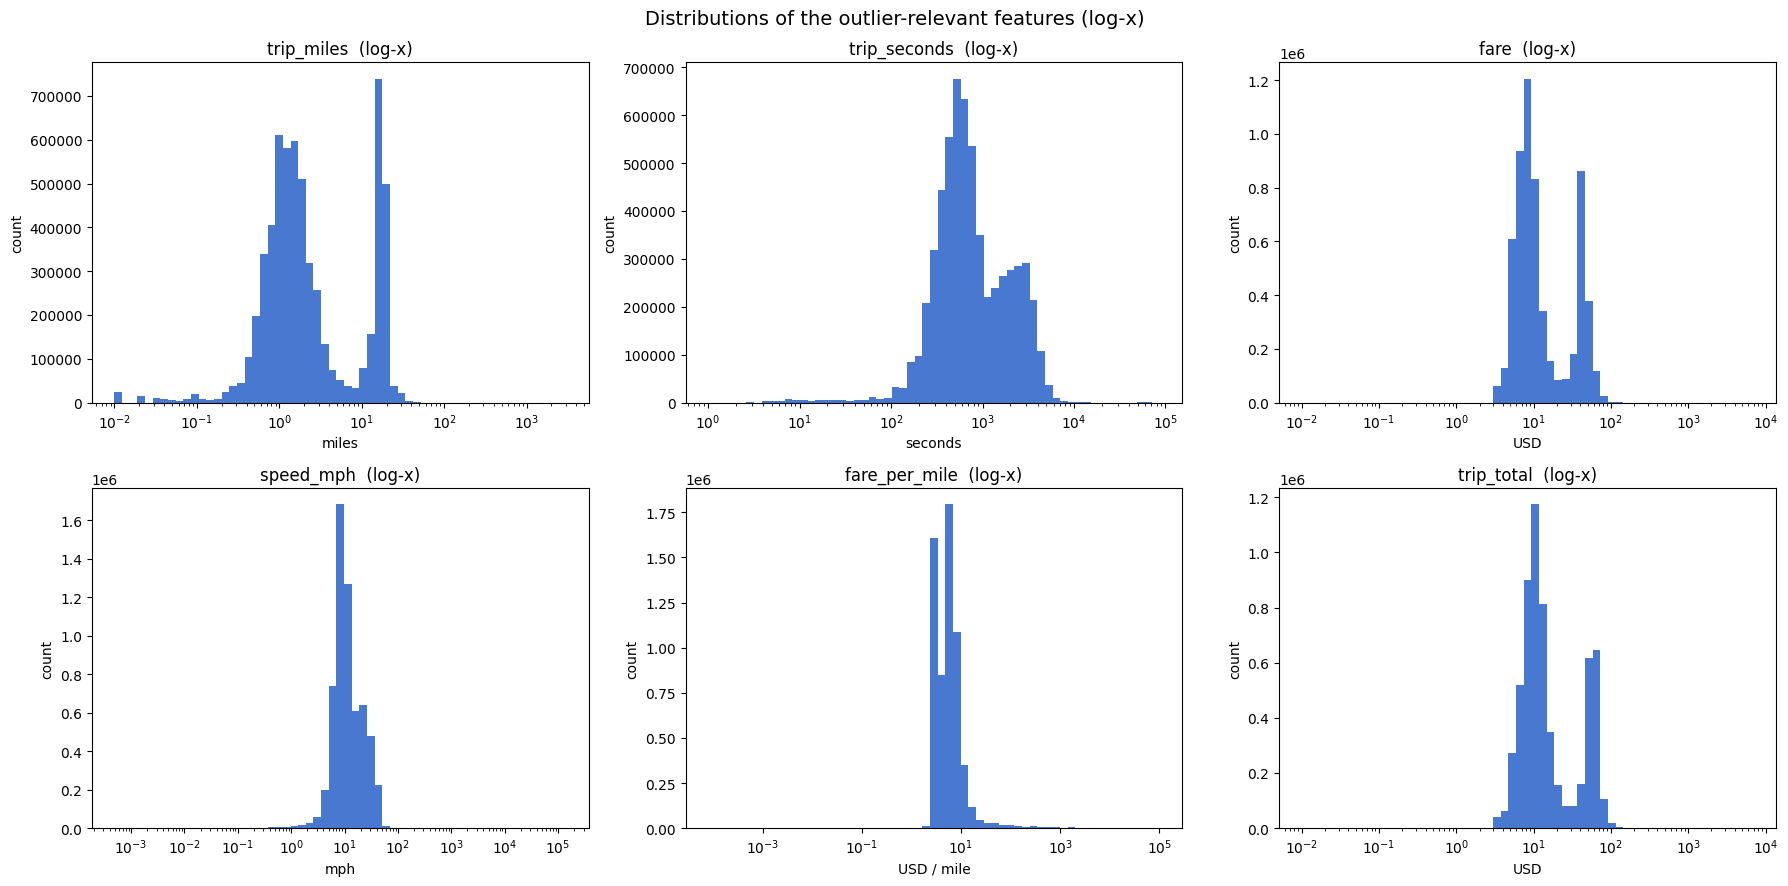

In [25]:
# Log-scaled histograms — with strongly right-skewed taxi distributions a linear axis shows just one bar
plot_feats = [
    ("trip_miles", "miles"), ("trip_seconds", "seconds"), ("fare", "USD"),
    ("speed_mph", "mph"), ("fare_per_mile", "USD / mile"), ("trip_total", "USD"),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (col, unit) in zip(axes.ravel(), plot_feats):
    vals = df_diag[col].replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]
    bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 60)
    ax.hist(vals, bins=bins, color=sns.color_palette("muted")[0], edgecolor="none")
    ax.set_xscale("log")
    ax.set_title(f"{col}  (log-x)")
    ax.set_xlabel(unit); ax.set_ylabel("count")
fig.suptitle("Distributions of the outlier-relevant features (log-x)", fontsize=14)
plt.tight_layout()
plt.show()

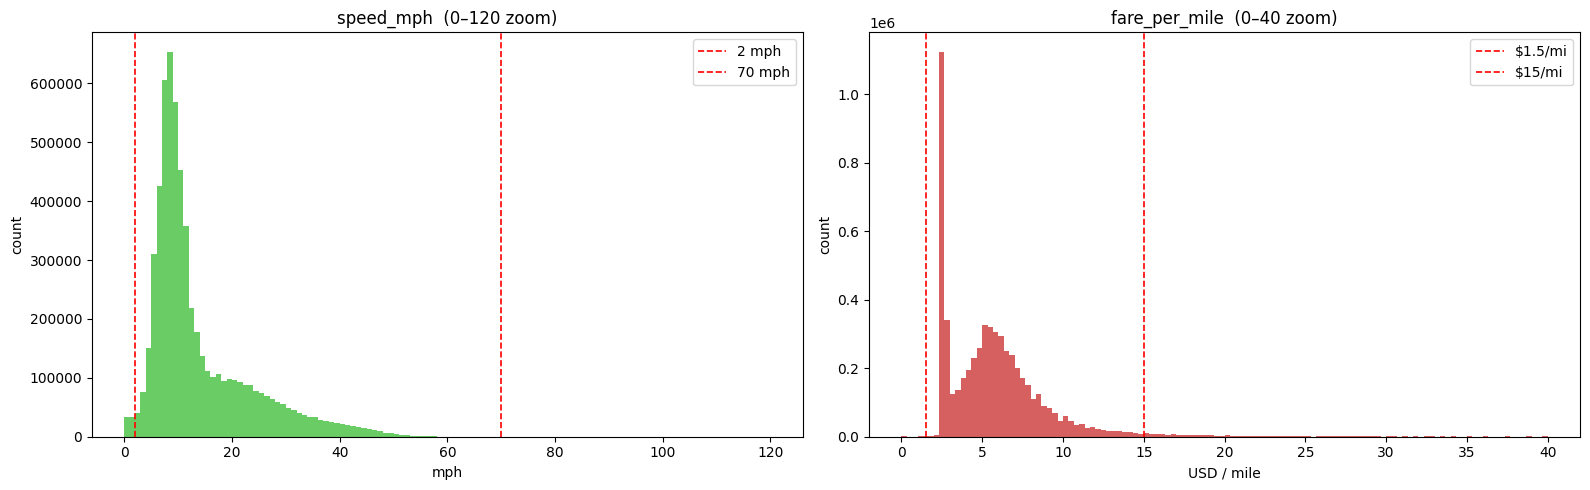

speed_mph      outside [2, 70] mph :   68,091 ( 1.13%)  | undefined (div0): 0
fare_per_mile  outside [1.5, 15] $/mi:  274,245 ( 4.56%)  | undefined (div0): 0


In [26]:
# Zoom into the two most important derived features, with candidate thresholds (red)
SPEED_LO, SPEED_HI = 2, 70      # mph      — candidate bounds, validate against the tails!
FPM_LO,   FPM_HI   = 1.5, 15    # USD/mile — candidate bounds, validate against the tails!

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

speed = df_diag["speed_mph"].dropna()
axes[0].hist(speed[speed.between(0, 120)], bins=120,
             color=sns.color_palette("muted")[2], edgecolor="none")
axes[0].axvline(SPEED_LO, color="red", ls="--", lw=1.2, label=f"{SPEED_LO} mph")
axes[0].axvline(SPEED_HI, color="red", ls="--", lw=1.2, label=f"{SPEED_HI} mph")
axes[0].set_title("speed_mph  (0–120 zoom)")
axes[0].set_xlabel("mph"); axes[0].set_ylabel("count"); axes[0].legend()

fpm = df_diag["fare_per_mile"].dropna()
axes[1].hist(fpm[fpm.between(0, 40)], bins=120,
             color=sns.color_palette("muted")[3], edgecolor="none")
axes[1].axvline(FPM_LO, color="red", ls="--", lw=1.2, label=f"${FPM_LO}/mi")
axes[1].axvline(FPM_HI, color="red", ls="--", lw=1.2, label=f"${FPM_HI}/mi")
axes[1].set_title("fare_per_mile  (0–40 zoom)")
axes[1].set_xlabel("USD / mile"); axes[1].set_ylabel("count"); axes[1].legend()

plt.tight_layout()
plt.show()

# Share outside the candidate corridors (NaN = undefined due to division by zero, reported separately)
for col, lo, hi, unit in [("speed_mph", SPEED_LO, SPEED_HI, "mph"),
                          ("fare_per_mile", FPM_LO, FPM_HI, "$/mi")]:
    s = df_diag[col]
    outside = (~s.between(lo, hi)) & s.notna()
    print(f"{col:<14} outside [{lo}, {hi}] {unit:<4}: {outside.sum():>8,} ({outside.mean():6.2%})"
          f"  | undefined (div0): {s.isna().sum():,}")

### Deep Dive: `trip_total` Consistency

The rule-violation table above flags a large share of trips where `trip_total ≠ fare + tips + tolls + extras`. A share that high is unlikely to be random — it points to a *systematic* cause, and the right treatment depends entirely on which one. Blindly recomputing `trip_total` from the component columns could discard a legitimate fee. So before deciding, we characterise the residual along three axes:

1. **Magnitude** — are the deviations cents (rounding noise, exaggerated by the strict `|d| > 0.01` cutoff) or dollars (real gaps)?
2. **Structure** — is the gap a recurring *constant* (a fixed fee/tax) or a smear of random values (corruption)?
3. **Drivers** — does it cluster by `payment_type`, `company`, or a specific `month` (a charge introduced on a date)?

In [27]:
# --- Magnitude: how large are the deviations, really? ---
# Signed residual: positive => trip_total exceeds the component sum (possible missing fee)
resid = df_diag["total_check"]   # = trip_total - (fare + tips + tolls + extras)

print("Signed residual (USD):")
display(resid.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3))

# Share of trips within increasing tolerance bands — separates rounding noise from real gaps
bands = [0.001, 0.01, 0.05, 0.10, 0.50, 1.00]
print("\nShare of trips within |residual| <= band:")
for b in bands:
    print(f"  |d| <= ${b:>5.3f} : {(resid.abs() <= b).mean():7.2%}")
print(f"  |d|  > ${bands[-1]:>5.2f} : {(resid.abs() > bands[-1]).mean():7.2%}")

Signed residual (USD):


count    6012355.000
mean           0.319
std            0.371
min           -0.000
1%             0.000
5%             0.000
50%            0.500
95%            0.500
99%            2.500
max            3.500
Name: total_check, dtype: float64


Share of trips within |residual| <= band:
  |d| <= $0.001 :  41.95%
  |d| <= $0.010 :  41.95%
  |d| <= $0.050 :  41.95%
  |d| <= $0.100 :  41.95%
  |d| <= $0.500 :  98.03%
  |d| <= $1.000 :  98.74%
  |d|  > $ 1.00 :   1.26%


In [28]:
# --- Structure: is the gap a constant (systematic fee) or random noise? ---
nonzero = resid[resid.abs() > 0.01]

print(f"Inconsistent trips (|d| > 0.01): {len(nonzero):,} ({len(nonzero) / len(resid):.1%})")
print(f"  positive (trip_total > sum): {(nonzero > 0).mean():.1%}")
print(f"  negative (trip_total < sum): {(nonzero < 0).mean():.1%}")

print("\nMost frequent residual values (rounded to cent) among inconsistent trips:")
display(nonzero.round(2).value_counts().head(12).to_frame("count"))

Inconsistent trips (|d| > 0.01): 3,490,097 (58.0%)
  positive (trip_total > sum): 100.0%
  negative (trip_total < sum): 0.0%

Most frequent residual values (rounded to cent) among inconsistent trips:


,count
total_check,
0.50,3413902
3.00,39826
2.50,35093
1.00,600
3.50,589
1.95,45
1.50,17
2.45,17
2.00,7


In [29]:
# --- Does the inconsistency cluster by payment type, company or over time? ---
tmp = df_diag[["payment_type", "company"]].copy()
tmp["resid"] = resid
tmp["inconsistent"] = resid.abs() > 0.01
tmp["month"] = df_diag["trip_start_timestamp"].dt.tz_localize(None).dt.to_period("M").astype(str)

def breakdown(col, top=10):
    g = tmp.groupby(col).agg(
        n=("resid", "size"),
        share_inconsistent=("inconsistent", "mean"),
        median_resid=("resid", "median"),
        mean_resid=("resid", "mean"),
    )
    return g.sort_values("n", ascending=False).head(top).round(3)

print("By payment_type:")
display(breakdown("payment_type"))

print("By company (top 10 by volume):")
display(breakdown("company"))

print("By month:")
display(
    tmp.groupby("month")
    .agg(n=("resid", "size"),
         share_inconsistent=("inconsistent", "mean"),
         median_resid=("resid", "median"))
    .round(3)
)

By payment_type:


,n,share_inconsistent,median_resid,mean_resid
payment_type,,,,
Credit Card,2804148,0.766,0.5,0.414
Mobile,1580516,0.828,0.5,0.424
Cash,1515294,0.022,0.0,0.056
Prcard,75326,0.003,0.0,0.008
Unknown,25391,0.000,0.0,0.000
No Charge,9601,0.000,0.0,0.000
Dispute,2079,0.000,0.0,0.000


By company (top 10 by volume):


,n,share_inconsistent,median_resid,mean_resid
company,,,,
Taxicab Insurance Agency Llc,927144,0.716,0.5,0.392
Sun Taxi,827996,0.722,0.5,0.398
Flash Cab,747682,0.648,0.5,0.361
City Service,716976,0.722,0.5,0.399
Taxi Affiliation Services,510458,0.000,0.0,-0.000
Chicago Independents,475774,0.700,0.5,0.377
Blue Ribbon Taxi Association,293831,0.667,0.5,0.369
Transit Administrative Center Inc,273269,0.000,0.0,0.000
5 Star Taxi,270654,0.718,0.5,0.391


By month:


,n,share_inconsistent,median_resid
month,,,
2024-01,133694,0.449,0.0
2024-02,144020,0.459,0.0
2024-03,182817,0.453,0.0
2024-04,198769,0.464,0.0
2024-05,242106,0.480,0.0
2024-06,245019,0.482,0.0
2024-07,201814,0.462,0.0
2024-08,214088,0.464,0.0
2024-09,219670,0.481,0.0


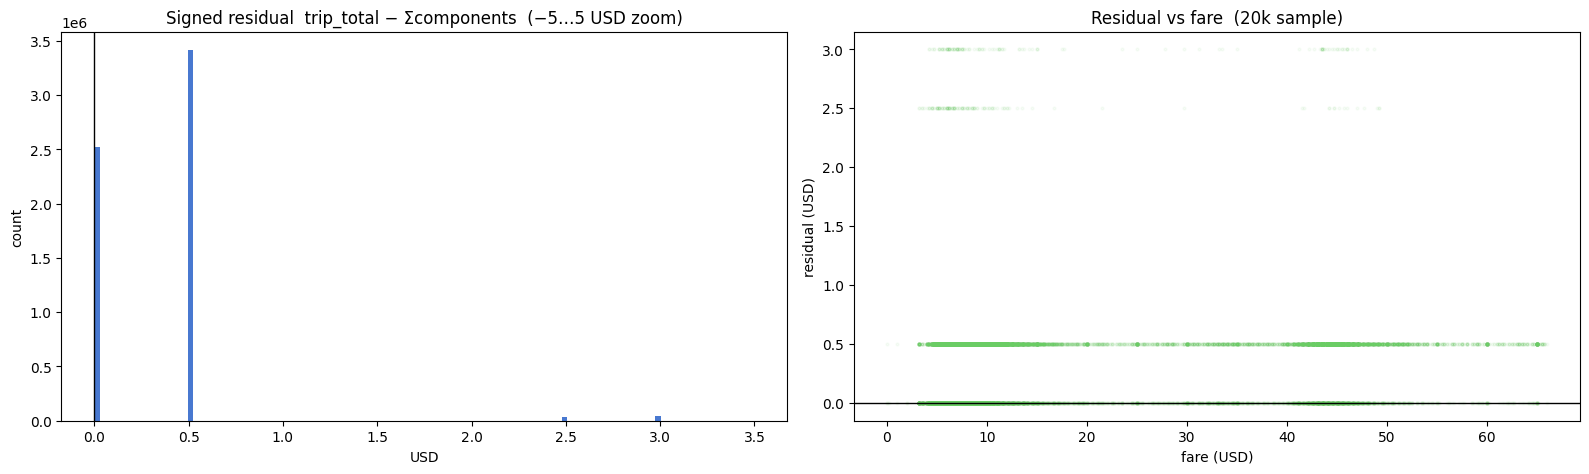

In [30]:
# --- Visualize the residual: shape and whether it scales with fare ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

r_zoom = resid[resid.between(-5, 5)]
axes[0].hist(r_zoom, bins=120, color=sns.color_palette("muted")[0], edgecolor="none")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Signed residual  trip_total − Σcomponents  (−5…5 USD zoom)")
axes[0].set_xlabel("USD"); axes[0].set_ylabel("count")

# Residual vs fare: a flat band => fixed fee; a diagonal => percentage charge
samp = pd.DataFrame({"fare": df_diag["fare"], "resid": resid}).dropna()
samp = samp[samp["fare"].between(0, samp["fare"].quantile(0.99)) & samp["resid"].between(-5, 5)]
samp = samp.sample(min(20_000, len(samp)), random_state=42)
axes[1].scatter(samp["fare"], samp["resid"], alpha=0.05, s=4, color=sns.color_palette("muted")[2])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Residual vs fare  (20k sample)")
axes[1].set_xlabel("fare (USD)"); axes[1].set_ylabel("residual (USD)")

plt.tight_layout()
plt.show()

**How to read this:**

- **Residual overwhelmingly within ±\$0.05** → the high "inconsistent" share is essentially float/rounding noise from the strict `|d| > 0.01` cutoff. Keep `trip_total` as-is and simply relax the tolerance; do **not** recompute.
- **A single constant dominates `value_counts` (e.g. +\$1.00)**, or the residual forms a flat positive band in the *residual-vs-fare* scatter → a **fixed fee/tax is missing** from the component columns. Recomputing `fare+tips+tolls+extras` would understate revenue — keep `trip_total`, or expose the gap as a `surcharge` feature.
- **Residual scales with fare** (diagonal in the scatter) → a **percentage charge** (e.g. a platform fee) is missing; again `trip_total` is the more complete figure.
- **Residual clusters on a `month`** → a charge introduced on a specific date; `trip_total` already reflects it while the components lag.
- **Large and structureless** → genuine corruption. Only then decide per use case (for price/revenue, trust `trip_total`; the components are the weaker signal).

Net: choose the treatment **after** seeing which pattern emerges above — do not blindly sum the component columns. Note that [03_spatial_analytics.ipynb](03_spatial_analytics.ipynb) currently rebuilds `trip_total = fare + tips` (dropping `tolls`/`extras`); if `trip_total` turns out reliable, that should switch back to the original column.

### Final Outlier Cutoffs

The diagnostics above expose where the distributions stop being physically plausible. We now fix the bounds. Two distinct treatments apply:

- **Rule 1 — drop (data errors):** records that are physically or operationally impossible. These are *not* demand and must leave the dataset entirely.
- **Rule 2 — cap / winsorize (genuine extremes):** rare but real values (long airport runs, high fares) that would dominate the scale-sensitive SVM / neural network. These are clipped to **p99.9** *only* when building model features — never dropped, so they still count as demand in the spatial/temporal aggregates.

We read each bound off the actual tails rather than using round numbers:

| Feature | Cutoff (drop) | Share | Justification |
|---|---|---|---|
| `fare` | `<= 0` | 0.03 % | A metered trip cannot bill \$0. |
| `trip_miles` | `> 100` | 0.001 % | Chicago metro spans ~50 mi; p99.9 = 32.4. >100 mi is geographically impossible. |
| `trip_seconds` | `> 10,800` (3 h) | 0.05 % | p99.9 = 7,624 s (2.1 h). Beyond 3 h the meter was left running. |
| `speed_mph` (high) | `> 70` | 0.04 % | p99.9 = 54.5; legal sustained max ~55–60 mph. The 141,000 mph max confirms GPS teleports live here. |
| `speed_mph` (low) | `< 2` | 1.09 % | Stuck-meter / under-recorded distance. **Most aggressive bound** — see note. |
| `fare_per_mile` (low) | `< 2.0` | ~1 % | **Strongest bound:** the \$2.25/mi tariff makes <\$2/mi impossible; the empirical p1 floors at 2.43, confirming it. |
| `fare_per_mile` (high) | `> 100` | ~1 % | p99 = 117.5. Genuine meter errors only start in the far tail. |

**Two cutoffs that required a judgment call (worth flagging in the report):**

1. **`speed_mph < 2` removes ~1 %, and the boundary is genuinely fuzzy.** A 0.4-mile trip (p5 of distance) over the median 660 s averages 2.2 mph — i.e. real gridlock sits right at the threshold. We keep `< 2` as the stuck-meter band but report the count so the choice is transparent; a more conservative analyst could use `< 1` or make it conditional on long duration.
2. **We deliberately do *not* apply a tight upper cap on `fare_per_mile`.** The candidate \$15/mi would drop ~5 % of trips (p95 = 14.2), but that tail is dominated by *legitimate short trips* where the fixed base fare inflates the ratio (a \$5, 0.3-mile trip = \$16.7/mi is valid). Only the far tail (`> 100`) is a true meter error.

The two most rigorously grounded bounds are `fare_per_mile < 2.0` (matches both the tariff and the empirical p1) and `speed_mph > 70` (above any legal sustained speed and p99.9).

These thresholds are wired into `preprocess_taxi_data()` in `scripts/helpers/preprocessing.py` as module-level constants (`SPEED_MIN_MPH`, `SPEED_MAX_MPH`, `TRIP_SECONDS_MAX`, `TRIP_MILES_MAX`, `FARE_PER_MILE_MIN`, `FARE_PER_MILE_MAX`). Below we apply them here for transparency — logging rows removed per rule — and run the sensitivity check the assignment requires (demand aggregate with vs. without the filters).

In [31]:
# ── Apply the final outlier cutoffs (Rule 1) and log rows removed per rule ──
# These mirror the constants in scripts/helpers/preprocessing.py exactly.
from scripts.helpers.preprocessing import (
    SPEED_MIN_MPH, SPEED_MAX_MPH, TRIP_SECONDS_MAX,
    TRIP_MILES_MAX, FARE_PER_MILE_MIN, FARE_PER_MILE_MAX,
)

speed = (df["trip_miles"] / (df["trip_seconds"] / 3600)).replace([np.inf, -np.inf], np.nan)
fpm   = (df["fare"]       /  df["trip_miles"]).replace([np.inf, -np.inf], np.nan)

rules = {
    "fare <= 0":                          df["fare"] <= 0,
    f"trip_miles > {TRIP_MILES_MAX:g}":   df["trip_miles"] > TRIP_MILES_MAX,
    "trip_seconds > 3 h":                 df["trip_seconds"] > TRIP_SECONDS_MAX,
    f"speed > {SPEED_MAX_MPH:g} mph":     speed > SPEED_MAX_MPH,
    f"speed < {SPEED_MIN_MPH:g} mph":     speed < SPEED_MIN_MPH,
    f"fare_per_mile < {FARE_PER_MILE_MIN:g}": fpm < FARE_PER_MILE_MIN,
    f"fare_per_mile > {FARE_PER_MILE_MAX:g}": fpm > FARE_PER_MILE_MAX,
}

n0 = len(df)
drop_any = pd.Series(False, index=df.index)
print(f"{'rule':<24}{'flagged':>12}{'share':>10}")
print("-" * 46)
for name, mask in rules.items():
    mask = mask.fillna(False)          # inf/NaN derived values -> treated as drop
    print(f"{name:<24}{mask.sum():>12,}{mask.mean():>10.3%}")
    drop_any |= mask

df_clean = df[~drop_any].copy()
print("-" * 46)
print(f"{'union (rows dropped)':<24}{drop_any.sum():>12,}{drop_any.mean():>10.3%}")
print(f"\n{n0:,} -> {len(df_clean):,} trips")

rule                         flagged     share
----------------------------------------------
fare <= 0                      1,799    0.030%
trip_miles > 100                  77    0.001%
trip_seconds > 3 h             2,764    0.046%
speed > 70 mph                 2,305    0.038%
speed < 2 mph                 65,786    1.094%
fare_per_mile < 2              7,598    0.126%
fare_per_mile > 100           67,995    1.131%
----------------------------------------------
union (rows dropped)         120,647    2.007%

6,012,355 -> 5,891,708 trips


In [32]:
# ── Sensitivity check: do the outlier filters distort the demand signal? ──
# If removing ~outliers materially reshaped the spatial demand we model later,
# the filters would be too aggressive. We compare per-community-area pickup
# demand before vs. after, expecting a near-identical geographic pattern.
before = df.groupby("pickup_community_area").size()
after  = df_clean.groupby("pickup_community_area").size()
comp = pd.concat([before, after], axis=1, keys=["before", "after"]).fillna(0)
comp["pct_change"] = (comp["after"] / comp["before"] - 1) * 100

print(f"Total pickups : {before.sum():,} -> {after.sum():,} "
      f"({after.sum() / before.sum() - 1:+.2%})")
print(f"Per-area demand correlation (before vs after): "
      f"{comp['before'].corr(comp['after']):.4f}")
print("\nMost-affected community areas (largest % change):")
display(comp.reindex(comp["pct_change"].abs().sort_values(ascending=False).index).head())

Total pickups : 6,012,355 -> 5,891,708 (-2.01%)
Per-area demand correlation (before vs after): 1.0000

Most-affected community areas (largest % change):


,before,after,pct_change
pickup_community_area,,,
26.0,1,0.0,-100.000000
70.0,1,0.0,-100.000000
67.0,2,1.0,-50.000000
27.0,3,2.0,-33.333333
62.0,3,2.0,-33.333333


## Loading & Preprocessing in Subsequent Notebooks

All steps documented above are encapsulated in two helper scripts so that later notebooks can load a clean dataset in a single line:

- **`scripts/helpers/datasets.py`** — entry point for loading any dataset. `load_taxi_data(preprocessed=True)` reads the raw CSV and optionally applies the full preprocessing pipeline.
- **`scripts/helpers/preprocessing.py`** — contains `preprocess_taxi_data()`, which imputes missing community areas, drops invalid rows, derives the temporal features (`hour`, `day_of_week`, `is_weekend`, `week`, `month`, `is_holiday`, `date`), and returns a clean `DataFrame`.

Usage in any subsequent notebook:

```python
from scripts.helpers.datasets import load_taxi_data, load_merged_data

df = load_taxi_data(preprocessed=True)       # cleaned dataset
df_raw = load_taxi_data(preprocessed=False)  # raw data only
df_merged = load_merged_data() # preprocessed taxi + weather data
```

## Summary: Cleaning Ledger

The table below consolidates every cleaning decision into a single audit trail — raw data through to the model-ready dataset — recording how many rows each step removes. It is **recomputed from the raw CSV in the exact order `preprocess_taxi_data()` applies**, so the figures tie out to the pipeline rather than being copied from the narrative above.

In [33]:
# ── Consolidated cleaning ledger (mirrors preprocess_taxi_data step-for-step) ──
import geopandas as gpd
from scripts.helpers.datasets import load_taxi_data
from scripts.helpers import preprocessing as pp

audit = load_taxi_data(preprocessed=False, feature_Engineering=True)

ledger = []
def _log(step, kind, frame):
    ledger.append({"step": step, "type": kind, "rows_remaining": len(frame)})

_log("Raw data (Chicago Data Portal)", "load", audit)

# 1 — Drop DST-ambiguous missing timestamps
audit = audit.dropna(subset=["trip_start_timestamp", "trip_end_timestamp"])
_log("Drop missing timestamps (DST artifacts)", "drop", audit)

# 2 — Impute missing community areas via spatial join (no rows removed)
ca = (gpd.read_file(pp.CA_GEOJSON_PATH)[["area_numbe", "geometry"]]
        .rename(columns={"area_numbe": "area_number"}))
ca["area_number"] = pd.to_numeric(ca["area_number"], errors="coerce")
audit = pp._fill_community_area(audit, "pickup_centroid_latitude",  "pickup_centroid_longitude",  "pickup_community_area",  ca)
audit = pp._fill_community_area(audit, "dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_community_area", ca)
_log("Impute missing community areas", "impute", audit)

# 3 — Drop missing taxi_id
audit = audit.dropna(subset=["taxi_id"])
_log("Drop missing taxi_id", "drop", audit)

# 4 — Drop ghost trips (zero duration, same location, start == end)
ghost = (
    (audit["trip_seconds"] == 0)
    & (audit["trip_end_timestamp"] == audit["trip_start_timestamp"])
    & (audit["pickup_centroid_latitude"]  == audit["dropoff_centroid_latitude"])
    & (audit["pickup_centroid_longitude"] == audit["dropoff_centroid_longitude"])
)
audit = audit[~ghost]
_log("Drop ghost trips (0 s, same location)", "drop", audit)

# 5 — Drop zero-mile trips with positive duration (GPS failures)
audit = audit[~((audit["trip_miles"] == 0) & (audit["trip_seconds"] > 0))]
_log("Drop zero-mile / positive-duration (GPS errors)", "drop", audit)

# 6 — Drop implausible outliers (Rule 1)
speed = (audit["trip_miles"] / (audit["trip_seconds"] / 3600)).replace([np.inf, -np.inf], np.nan)
fpm   = (audit["fare"]       /  audit["trip_miles"]).replace([np.inf, -np.inf], np.nan)
keep = (
    (audit["fare"] > 0)
    & (audit["trip_miles"] <= pp.TRIP_MILES_MAX)
    & (audit["trip_seconds"] <= pp.TRIP_SECONDS_MAX)
    & speed.between(pp.SPEED_MIN_MPH, pp.SPEED_MAX_MPH)
    & fpm.between(pp.FARE_PER_MILE_MIN, pp.FARE_PER_MILE_MAX)
)
audit = audit[keep]
_log("Drop implausible outliers (Rule 1)", "drop", audit)

# ── Assemble the ledger table ──
ledger_df = pd.DataFrame(ledger)
n_raw = ledger_df["rows_remaining"].iloc[0]
ledger_df["rows_removed"]    = (-ledger_df["rows_remaining"].diff()).fillna(0).astype(int)
ledger_df["pct_raw_removed"] = (ledger_df["rows_removed"] / n_raw * 100).round(3)
ledger_df["pct_retained"]    = (ledger_df["rows_remaining"] / n_raw * 100).round(2)
ledger_df = ledger_df[["step", "type", "rows_removed", "rows_remaining", "pct_raw_removed", "pct_retained"]]

n_final = ledger_df["rows_remaining"].iloc[-1]
print(f"Raw -> clean: {n_raw:,} -> {n_final:,} trips "
      f"({n_final / n_raw:.2%} retained, {1 - n_final / n_raw:.2%} removed)")
display(ledger_df.style.hide(axis="index"))

Raw -> clean: 6,593,828 -> 5,891,622 trips (89.35% retained, 10.65% removed)


step,type,rows_removed,rows_remaining,pct_raw_removed,pct_retained
Raw data (Chicago Data Portal),load,0,6593828,0.000000,100.000000
Drop missing timestamps (DST artifacts),drop,115,6593713,0.002000,100.000000
Impute missing community areas,impute,0,6593713,0.000000,100.000000
Drop missing taxi_id,drop,4,6593709,0.000000,100.000000
"Drop ghost trips (0 s, same location)",drop,83220,6510489,1.262000,98.740000
Drop zero-mile / positive-duration (GPS errors),drop,496056,6014433,7.523000,91.210000
Drop implausible outliers (Rule 1),drop,122811,5891622,1.863000,89.350000
